In [ ]:
# # Export centralized plots
# export_service.export_confusion_matrix_display(
#     cm=cm_all,
#     labels=["No-Stress", "Stress"],
#     mongo_id=mongo_id,
#     path=BASE_PATH,
#     which="centralized",
# )
# export_service.export_roc_display(
#     mongo_id=mongo_id,
#     x_test=x_test_all,
#     y_test=y_test_all,
#     path=BASE_PATH,
#     model=model.get_fitted_model(),
#     which="centralized",
# )
#
# # Export individual results
# for subject in range(2, 36):
#     x_test = dataset_service.load_testing_features(which=subject, with_features=with_features).to_numpy()
#     y_test = dataset_service.load_testing_labels(which=subject, with_features=with_features).to_numpy()
#
#     pred_test = model.predict(x=x_test)
#     scores_test, cm = model.evaluate(pred=pred_test, y_true=y_test)
#
#     export_service.export_confusion_matrix_display(
#         cm=cm,
#         labels=["No-Stress", "Stress"],
#         mongo_id=mongo_id,
#         path=BASE_PATH,
#         which=subject,
#     )
#     export_service.export_roc_display(
#         mongo_id=mongo_id,
#         x_test=x_test,
#         y_test=y_test,
#         path=BASE_PATH,
#         model=model.get_fitted_model(),
#         which=subject,
#     )

In [1]:
from pathlib import Path
import joblib
import pandas as pd

from model.DNNModel import DNNModel
from service.datasetservice.DatasetService import DatasetService
from service.exportservice.ExportService import ExportService

dataset_service = DatasetService()
export_service = ExportService()
x_test_all = dataset_service.load_testing_features(which="all", with_features=True)
x_test_all = pd.concat(x_test_all).to_numpy()
y_test_all = dataset_service.load_testing_labels(which="all", with_features=True)
y_test_all = pd.concat(y_test_all).to_numpy()

run_id = "ba563c76aab7b30a0d18609afa30024304e112a90d54f5c74e85f139e47a126e"
BASE_PATH = Path("../results/centralized/plots")
model: DNNModel = joblib.load(f"../results/centralized/models/{run_id}.joblib")
pred_test_all = model.predict(x_test_all)
scores_test_all, cm_all = model.evaluate(pred=pred_test_all, y_true=y_test_all)

In [6]:
from imblearn.pipeline import Pipeline

pipeline: Pipeline = model.get_fitted_model()

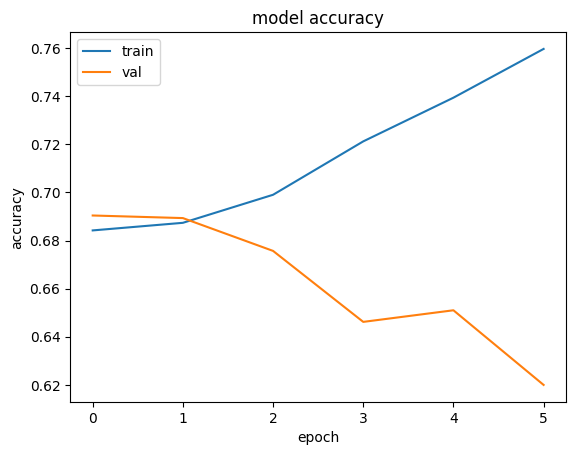

In [34]:
from matplotlib import pyplot as plt

history = pipeline.named_steps["clf"].history_

plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()